In [40]:
from dotenv import load_dotenv
import pm4py
import warnings
import pandas as pd
import os
load_dotenv()

True

In [41]:
warnings.filterwarnings("ignore")
log = pm4py.read_xes("../data/bpi-log.xes")
log.head()

parsing log, completed traces :: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 13087/13087 [00:00<00:00, 23485.30it/s]


,case:REG_DATE,org:resource,concept:name,lifecycle:transition,case:AMOUNT_REQ,time:timestamp,case:concept:name
0,2011-10-01 02:38:00+00:00,112,submitted,COMPLETE,20000,2011-10-01 02:38:00+00:00,173688
1,2011-10-01 02:38:00+00:00,112,pre-accepted,COMPLETE,20000,2011-10-01 02:39:00+00:00,173688
2,2011-10-01 02:38:00+00:00,10862,accepted,COMPLETE,20000,2011-10-01 13:42:00+00:00,173688
3,2011-10-01 02:38:00+00:00,10862,finalized,COMPLETE,20000,2011-10-01 13:45:00+00:00,173688
4,2011-10-01 02:38:00+00:00,10629,registered,COMPLETE,20000,2011-10-13 12:37:00+00:00,173688


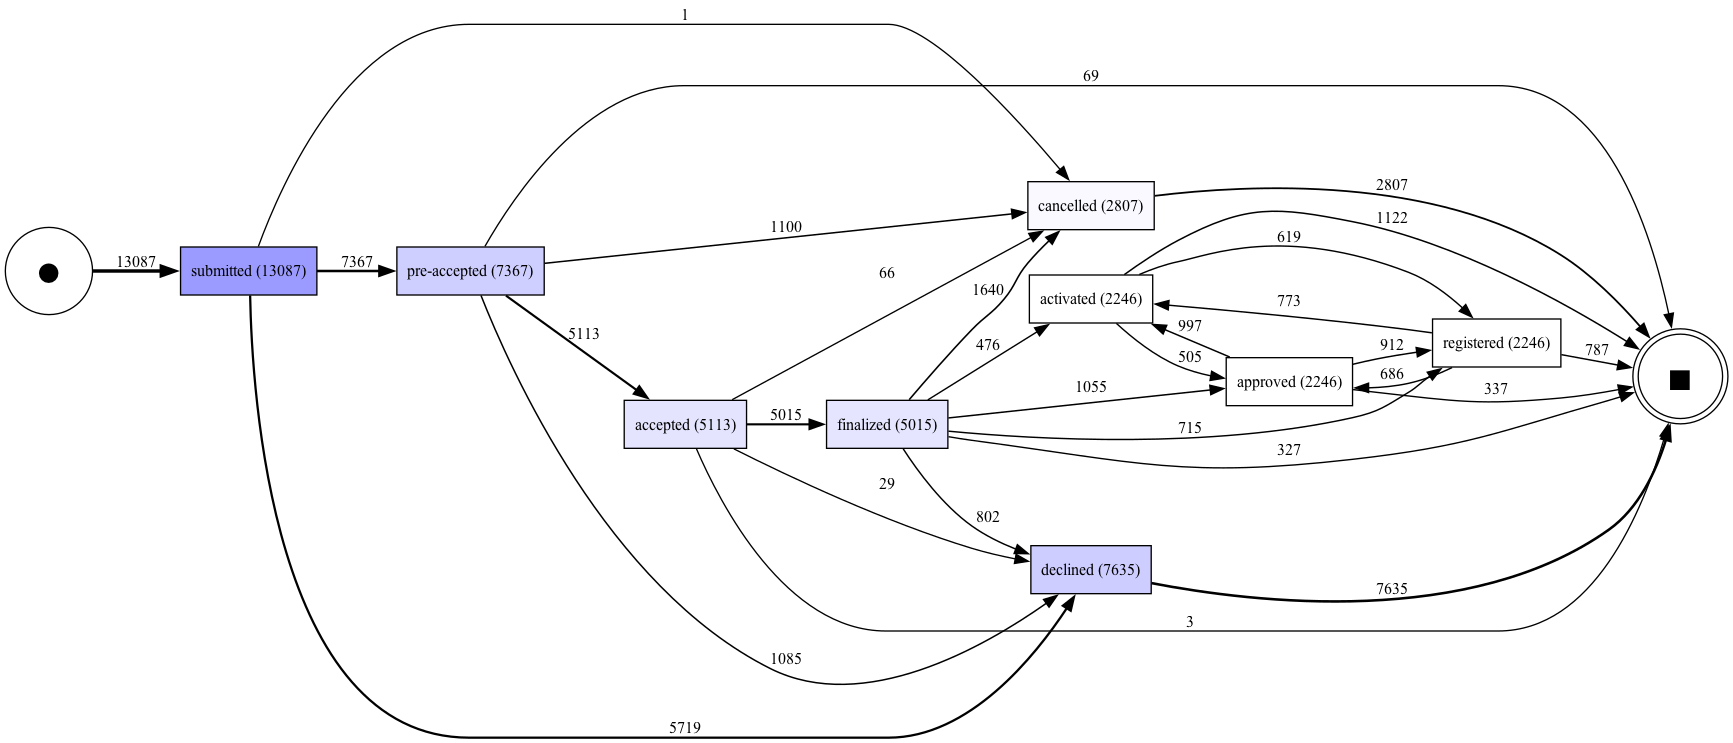

In [42]:
dfg, sa, ea = pm4py.discover_dfg(log)
pm4py.view_dfg(dfg, sa, ea)

In [43]:
abstraction = pm4py.llm.abstract_dfg(
    log, include_performance=True, relative_frequency=True, max_len=8000
)
print(abstraction)

If I have a process with flow:

submitted -> pre-accepted ( frequency = 56\%  performance = 7484.623 )
submitted -> declined ( frequency = 43\%  performance = 10351.747 )
pre-accepted -> accepted ( frequency = 39\%  performance = 67242.844 )
accepted -> finalized ( frequency = 38\%  performance = 564.718 )
finalized -> cancelled ( frequency = 12\%  performance = 1858345.024 )
pre-accepted -> declined ( frequency = 8\%  performance = 125712.940 )
pre-accepted -> cancelled ( frequency = 8\%  performance = 1182611.673 )
finalized -> approved ( frequency = 8\%  performance = 1396517.118 )
approved -> activated ( frequency = 7\%  performance = 0.000 )
finalized -> declined ( frequency = 6\%  performance = 1335740.200 )
approved -> registered ( frequency = 6\%  performance = 0.000 )
registered -> approved ( frequency = 5\%  performance = 0.000 )
registered -> activated ( frequency = 5\%  performance = 0.000 )
finalized -> registered ( frequency = 5\%  performance = 1375289.622 )
activated ->

In [44]:
# Cell 3 — the LLM call
answer = pm4py.llm.anthropic_query(
    abstraction + "\n\nWhich paths are the biggest bottlenecks, and what does the "
                  "frequency/duration pattern suggest about the process? Be concise.",
    model="claude-sonnet-5",
    api_key=os.environ["PM4PY_ANTHROPIC_API_KEY"],
    extra_payload={"output_config": {"effort": "medium"}},
)
print(answer)

## Biggest Bottlenecks (by performance/duration)

1. **finalized → cancelled** (1,858,345 — highest duration, 12% frequency): The single largest time sink in the process, likely representing cases stuck or abandoned after finalization.
2. **finalized → approved** (1,396,517, 8%) and **finalized → registered** (1,375,289, 5%): Long waits after finalization, suggesting an approval/registration bottleneck stage.
3. **finalized → activated** (1,356,652, 3%) and **finalized → declined** (1,335,740, 6%): Same pattern — long delays regardless of outcome.
4. **pre-accepted → cancelled** (1,182,611, 8%): Significant early-stage bottleneck as well.
5. **pre-accepted → declined** (125,712, 8%): Smaller but still notable delay.

## Pattern Insights

- **The "finalized" state is the core bottleneck.** Every transition out of it (to cancelled, approved, declined, registered, activated) takes over 1.3 million time units — orders of magnitude higher than earlier stages (submitted, pre-accepted, accept